In [ ]:
!pip install wfdb

import wfdb
import numpy as np

def load_physionet_emg():
    """Loads all three PhysioNet emgdb recordings directly from their servers."""
    records = {}
    for name in ['emg_healthy', 'emg_myopathy', 'emg_neuropathy']:
        rec = wfdb.rdrecord(name, pn_dir='emgdb')
        records[name] = {
            'signal': rec.p_signal.flatten(),  # single channel
            'fs': rec.fs
        }
        print(f"{name}: {len(records[name]['signal'])} samples @ {rec.fs} Hz")
    return records

physionet_data = load_physionet_emg()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.3 MB/s eta 0:00:00
emg_healthy: 50860 samples @ 4000 Hz
emg_myopathy: 110337 samples @ 4000 Hz
emg_neuropathy: 147858 samples @ 4000 Hz


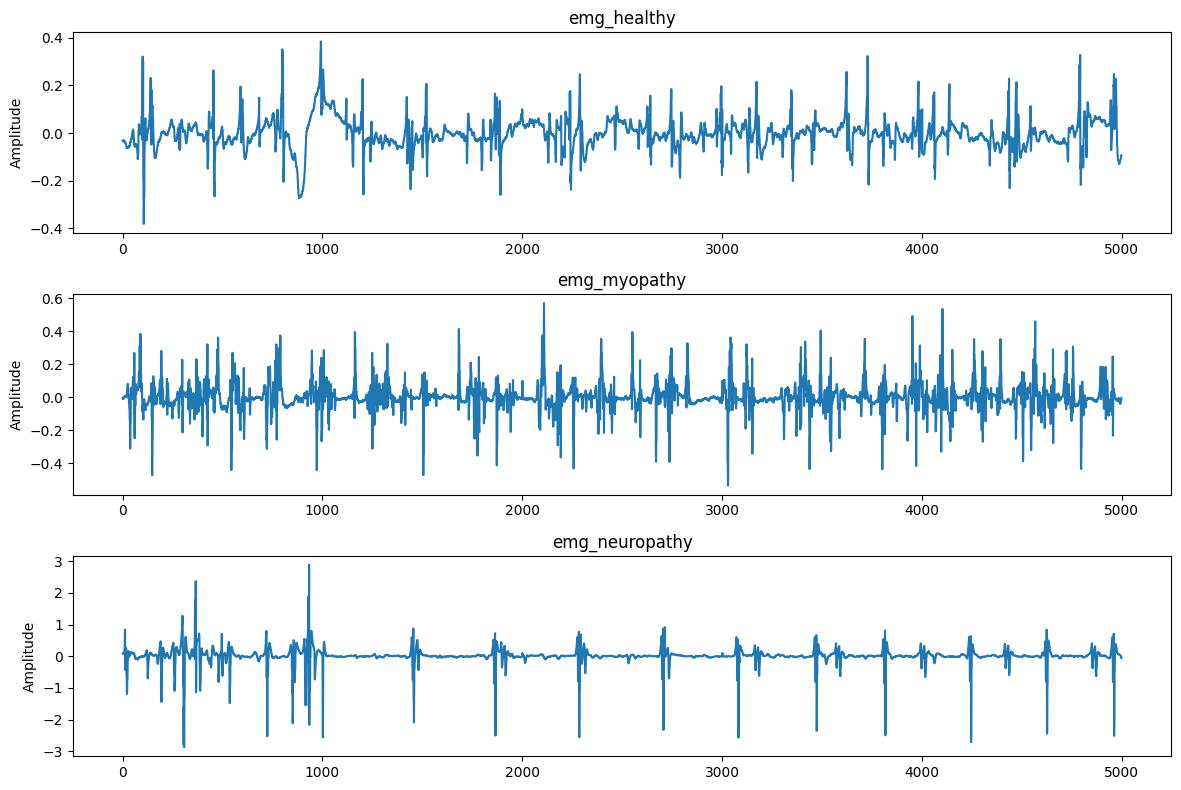

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
for ax, (name, rec) in zip(axes, physionet_data.items()):
    ax.plot(rec['signal'][:5000])  # first ~1.25 sec
    ax.set_title(name)
    ax.set_ylabel('Amplitude')
plt.tight_layout()
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

drive_zip_dir = '/content/drive/MyDrive/ninapro'   # zips live here, in Drive
extract_dir = '/content/ninapro_db1'                     # extracted here, in Colab's local disk

os.makedirs(extract_dir, exist_ok=True)

for s in range(1, 28):  # start with subjects 1-5
    zip_path = os.path.join(drive_zip_dir, f's{s}.zip')
    subj_path = os.path.join(extract_dir, f's{s}')
    os.makedirs(subj_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(subj_path)
    print(f"Extracted subject {s}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted subject 1
Extracted subject 2
Extracted subject 3
Extracted subject 4
Extracted subject 5
Extracted subject 6
Extracted subject 7
Extracted subject 8
Extracted subject 9
Extracted subject 10
Extracted subject 11
Extracted subject 12
Extracted subject 13
Extracted subject 14
Extracted subject 15
Extracted subject 16
Extracted subject 17
Extracted subject 18
Extracted subject 19
Extracted subject 20
Extracted subject 21
Extracted subject 22
Extracted subject 23
Extracted subject 24
Extracted subject 25
Extracted subject 26
Extracted subject 27


In [ ]:
print(os.listdir(os.path.join(extract_dir, 's1')))

['S1_A1_E2.mat', 'S1_A1_E1.mat', 'S1_A1_E3.mat']


In [ ]:
from scipy.io import loadmat
import numpy as np

def load_ninapro_subject(base_dir, subject_num, exercise_num=2):
    subj_dir = os.path.join(base_dir, f"s{subject_num}")
    fname = f"S{subject_num}_A1_E{exercise_num}.mat"
    fpath = os.path.join(subj_dir, fname)
    data = loadmat(fpath)
    return {
        'emg': data['emg'],
        'restimulus': data['restimulus'].flatten(),
        'rerepetition': data['rerepetition'].flatten()
    }

s1_data = load_ninapro_subject(extract_dir, subject_num=1, exercise_num=2)

print("EMG shape:", s1_data['emg'].shape)
print("Restimulus shape:", s1_data['restimulus'].shape)
print("Rerepetition shape:", s1_data['rerepetition'].shape)
print("Unique movements (restimulus):", np.unique(s1_data['restimulus']))
print("Unique repetitions (rerepetition):", np.unique(s1_data['rerepetition']))

EMG shape: (142976, 10)
Restimulus shape: (142976,)
Rerepetition shape: (142976,)
Unique movements (restimulus): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
Unique repetitions (rerepetition): [ 0  1  2  3  4  5  6  7  8  9 10]


In [ ]:
def load_all_subjects(base_dir, n_subjects=27, exercise_num=2):
    all_data = {}
    for s in range(1, n_subjects + 1):
        try:
            all_data[s] = load_ninapro_subject(base_dir, s, exercise_num)
            print(f"Loaded subject {s}: {all_data[s]['emg'].shape[0]} samples")
        except FileNotFoundError:
            print(f"⚠️  Subject {s} file not found — skipping")
    return all_data

all_subjects_data = load_all_subjects(extract_dir, n_subjects=27, exercise_num=2)

Loaded subject 1: 142976 samples
Loaded subject 2: 142731 samples
Loaded subject 3: 142682 samples
Loaded subject 4: 142977 samples
Loaded subject 5: 142726 samples
Loaded subject 6: 142957 samples
Loaded subject 7: 143133 samples
Loaded subject 8: 142773 samples
Loaded subject 9: 142887 samples
Loaded subject 10: 142914 samples
Loaded subject 11: 142944 samples
Loaded subject 12: 142663 samples
Loaded subject 13: 142797 samples
Loaded subject 14: 143028 samples
Loaded subject 15: 143975 samples
Loaded subject 16: 142766 samples
Loaded subject 17: 144333 samples
Loaded subject 18: 143460 samples
Loaded subject 19: 142999 samples
Loaded subject 20: 144257 samples
Loaded subject 21: 144145 samples
Loaded subject 22: 143962 samples
Loaded subject 23: 143528 samples
Loaded subject 24: 143833 samples
Loaded subject 25: 143978 samples
Loaded subject 26: 144111 samples
Loaded subject 27: 143033 samples


In [ ]:
def window_signal(emg, labels, reps, window_size=200, step=100):
    """
    Segment continuous EMG into overlapping windows.
    Keeps only windows where label AND repetition are constant throughout
    (avoids mixing two movements or two reps in one window).
    """
    X, y, rep_ids = [], [], []
    for start in range(0, len(emg) - window_size, step):
        end = start + window_size
        window = emg[start:end]
        label_window = labels[start:end]
        rep_window = reps[start:end]

        if len(np.unique(label_window)) == 1 and len(np.unique(rep_window)) == 1:
            X.append(window)
            y.append(label_window[0])
            rep_ids.append(rep_window[0])

    return np.array(X), np.array(y), np.array(rep_ids)


def build_full_dataset(all_subjects_data, window_size=200, step=100):
    all_X, all_y, all_reps, all_subj = [], [], [], []

    for subj_id, data in all_subjects_data.items():
        X, y, reps = window_signal(
            data['emg'], data['restimulus'], data['rerepetition'],
            window_size=window_size, step=step
        )
        all_X.append(X)
        all_y.append(y)
        all_reps.append(reps)
        all_subj.append(np.full(len(y), subj_id))
        print(f"Subject {subj_id}: {X.shape[0]} windows generated")

    return (np.concatenate(all_X), np.concatenate(all_y),
            np.concatenate(all_reps), np.concatenate(all_subj))


X, y, reps, subj = build_full_dataset(all_subjects_data)
print("\nFinal dataset shape:", X.shape)
print("Labels shape:", y.shape)
print("Class distribution:", np.unique(y, return_counts=True))

Subject 1: 751 windows generated
Subject 2: 750 windows generated
Subject 3: 748 windows generated
Subject 4: 754 windows generated
Subject 5: 749 windows generated
Subject 6: 750 windows generated
Subject 7: 753 windows generated
Subject 8: 750 windows generated
Subject 9: 754 windows generated
Subject 10: 752 windows generated
Subject 11: 756 windows generated
Subject 12: 748 windows generated
Subject 13: 753 windows generated
Subject 14: 753 windows generated
Subject 15: 761 windows generated
Subject 16: 748 windows generated
Subject 17: 771 windows generated
Subject 18: 755 windows generated
Subject 19: 749 windows generated
Subject 20: 764 windows generated
Subject 21: 766 windows generated
Subject 22: 761 windows generated
Subject 23: 758 windows generated
Subject 24: 759 windows generated
Subject 25: 763 windows generated
Subject 26: 764 windows generated
Subject 27: 754 windows generated

Final dataset shape: (20394, 200, 10)
Labels shape: (20394,)
Class distribution: (array([ 

In [ ]:
train_reps = [1, 2, 3, 4, 6, 7, 8]
val_reps = [5]
test_reps = [9, 10]

train_mask = np.isin(reps, train_reps)
val_mask = np.isin(reps, val_reps)
test_mask = np.isin(reps, test_reps)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (5092, 200, 10) Val: (731, 200, 10) Test: (1449, 200, 10)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights))
print(class_weight_dict)

{np.uint8(1): np.float64(0.8533601474777945), np.uint8(2): np.float64(0.9478778853313478), np.uint8(3): np.float64(1.0051322542439796), np.uint8(4): np.float64(0.9852941176470589), np.uint8(5): np.float64(1.2175992348158775), np.uint8(6): np.float64(1.296664120193532), np.uint8(7): np.float64(1.0400326797385622), np.uint8(8): np.float64(1.0293106933495046), np.uint8(9): np.float64(0.8941176470588236), np.uint8(10): np.float64(0.9885459134148709), np.uint8(11): np.float64(0.8861816916115559), np.uint8(12): np.float64(0.991819244253993), np.uint8(13): np.float64(0.9569629768840443), np.uint8(14): np.float64(1.3371848739495797), np.uint8(15): np.float64(1.2585269401878398), np.uint8(16): np.float64(0.8051865907653384), np.uint8(17): np.float64(0.8758169934640523)}


In [ ]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [ ]:
sorted_classes = sorted(class_weight_dict.keys())
print(sorted_classes)

weights_tensor = torch.tensor(
    [class_weight_dict[c] for c in sorted_classes],
    dtype=torch.float32
).to(device)

print(weights_tensor)

[np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(10), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(14), np.uint8(15), np.uint8(16), np.uint8(17)]
tensor([0.8534, 0.9479, 1.0051, 0.9853, 1.2176, 1.2967, 1.0400, 1.0293, 0.8941,
        0.9885, 0.8862, 0.9918, 0.9570, 1.3372, 1.2585, 0.8052, 0.8758],
       device='cuda:0')


In [ ]:
import torch.nn.functional as F

class EMG_CNN(nn.Module):
    def __init__(self, n_channels=10, n_classes=17):
        super().__init__()
        # Conv layers operate along the time axis; input needs to be (batch, channels, time)
        self.conv1 = nn.Conv1d(n_channels, 32, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)

        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)

        # After 3 pooling ops on a length-200 input: 200 -> 100 -> 50 -> 25
        self.fc1 = nn.Linear(128 * 25, 128)
        self.fc2 = nn.Linear(128, n_classes)

    def forward(self, x):
        # x comes in as (batch, time, channels) -> need (batch, channels, time) for Conv1d
        x = x.permute(0, 2, 1)

        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.flatten(1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)  # raw logits, CrossEntropyLoss applies softmax internally
        return x

model = EMG_CNN(n_channels=10, n_classes=17).to(device)
print(model)


EMG_CNN(
  (conv1): Conv1d(10, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=3200, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=17, bias=True)
)


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train_mapped, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val_mapped, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test_mapped, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

print("Batches per epoch:", len(train_loader))

Batches per epoch: 80


In [41]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)  # class weights from earlier

n_epochs = 30
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

best_f1 = 0
best_model_state = None

from sklearn.metrics import f1_score

for epoch in range(n_epochs):
    # --- Training ---
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # --- Validation ---
    model.eval()
    val_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    val_loss /= len(val_loader)
    val_f1 = f1_score(all_labels, all_preds, average='macro')

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    # --- Checkpoint the best model, inside the loop this time ---
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_model_state = model.state_dict().copy()
        print(f"  → New best model saved (F1: {val_f1:.4f})")

    print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro-F1: {val_f1:.4f}")

print(f"\nBest val Macro-F1 achieved: {best_f1:.4f}")

  → New best model saved (F1: 0.8500)
Epoch 1/30 | Train Loss: 0.3930 | Val Loss: 0.5960 | Val Macro-F1: 0.8500
  → New best model saved (F1: 0.8510)
Epoch 2/30 | Train Loss: 0.3597 | Val Loss: 0.5427 | Val Macro-F1: 0.8510
Epoch 3/30 | Train Loss: 0.3515 | Val Loss: 0.6037 | Val Macro-F1: 0.8295
Epoch 4/30 | Train Loss: 0.3607 | Val Loss: 0.6188 | Val Macro-F1: 0.8387
Epoch 5/30 | Train Loss: 0.3326 | Val Loss: 0.6082 | Val Macro-F1: 0.8358
Epoch 6/30 | Train Loss: 0.3511 | Val Loss: 0.5726 | Val Macro-F1: 0.8462
Epoch 7/30 | Train Loss: 0.3258 | Val Loss: 0.5477 | Val Macro-F1: 0.8426
Epoch 8/30 | Train Loss: 0.3301 | Val Loss: 0.6345 | Val Macro-F1: 0.8424
Epoch 9/30 | Train Loss: 0.3121 | Val Loss: 0.6045 | Val Macro-F1: 0.8477
  → New best model saved (F1: 0.8510)
Epoch 10/30 | Train Loss: 0.2692 | Val Loss: 0.5881 | Val Macro-F1: 0.8510
  → New best model saved (F1: 0.8592)
Epoch 11/30 | Train Loss: 0.2921 | Val Loss: 0.5375 | Val Macro-F1: 0.8592
Epoch 12/30 | Train Loss: 0.3161

In [43]:
model.load_state_dict(best_model_state)
model.eval()
test_preds, test_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(y_batch.numpy())

from sklearn.metrics import classification_report
cnn_test_f1 = f1_score(test_labels, test_preds, average='macro')
print("Test Macro-F1:", cnn_test_f1)
print(classification_report(test_labels, test_preds))

Test Macro-F1: 0.8214387750270574
              precision    recall  f1-score   support

           0       0.78      0.81      0.79       107
           1       0.85      0.81      0.83        93
           2       0.85      0.88      0.87        77
           3       0.72      0.79      0.75        85
           4       0.70      0.64      0.67        66
           5       0.79      0.75      0.77        67
           6       0.82      0.89      0.85        94
           7       0.77      0.82      0.80        91
           8       0.85      0.76      0.80        89
           9       0.89      0.74      0.81        88
          10       0.85      0.82      0.83        98
          11       0.74      0.84      0.78        85
          12       0.90      0.94      0.92        81
          13       0.92      0.84      0.88        67
          14       0.77      0.83      0.80        64
          15       0.91      0.88      0.90       103
          16       0.91      0.93      0.92    

In [ ]:
import numpy as np

def extract_features(window):
    features = []
    for ch in range(window.shape[1]):
        signal = window[:, ch]

        rms = np.sqrt(np.mean(signal ** 2))
        mav = np.mean(np.abs(signal))
        zc = np.sum(np.diff(np.sign(signal)) != 0)
        wl = np.sum(np.abs(np.diff(signal)))
        var = np.var(signal)

        freqs = np.fft.rfftfreq(len(signal), d=1.0)
        fft_mag = np.abs(np.fft.rfft(signal))
        mean_freq = np.sum(freqs * fft_mag) / (np.sum(fft_mag) + 1e-8)

        features.extend([rms, mav, zc, wl, var, mean_freq])

    return np.array(features)


def extract_features_batch(X):
    return np.array([extract_features(w) for w in X])


print("Extracting train features...")
X_train_feat = extract_features_batch(X_train)
print("Train done:", X_train_feat.shape)

print("Extracting val features...")
X_val_feat = extract_features_batch(X_val)
print("Val done:", X_val_feat.shape)

print("Extracting test features...")
X_test_feat = extract_features_batch(X_test)
print("Test done:", X_test_feat.shape)

Extracting train features...
Train done: (5092, 60)
Extracting val features...
Val done: (731, 60)
Extracting test features...
Test done: (1449, 60)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_feat_scaled = scaler.fit_transform(X_train_feat)
X_val_feat_scaled = scaler.transform(X_val_feat)
X_test_feat_scaled = scaler.transform(X_test_feat)

print("Scaled shapes:", X_train_feat_scaled.shape, X_val_feat_scaled.shape, X_test_feat_scaled.shape)

Scaled shapes: (5092, 60) (731, 60) (1449, 60)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_feat_scaled, y_train_mapped)

rf_test_preds = rf.predict(X_test_feat_scaled)
rf_test_f1 = f1_score(y_test_mapped, rf_test_preds, average='macro')
print("Random Forest Test Macro-F1:", rf_test_f1)
print(classification_report(y_test_mapped, rf_test_preds))

Random Forest Test Macro-F1: 0.7968280355395111
              precision    recall  f1-score   support

           0       0.72      0.81      0.76       107
           1       0.82      0.87      0.84        93
           2       0.78      0.87      0.82        77
           3       0.76      0.71      0.73        85
           4       0.74      0.53      0.62        66
           5       0.88      0.69      0.77        67
           6       0.73      0.88      0.80        94
           7       0.67      0.68      0.68        91
           8       0.73      0.75      0.74        89
           9       0.86      0.75      0.80        88
          10       0.78      0.74      0.76        98
          11       0.77      0.88      0.82        85
          12       0.89      0.86      0.88        81
          13       0.93      0.84      0.88        67
          14       0.87      0.83      0.85        64
          15       0.92      0.86      0.89       103
          16       0.86      0.94

In [ ]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42
)
svm.fit(X_train_feat_scaled, y_train_mapped)

svm_test_preds = svm.predict(X_test_feat_scaled)
svm_test_f1 = f1_score(y_test_mapped, svm_test_preds, average='macro')
print("SVM Test Macro-F1:", svm_test_f1)
print(classification_report(y_test_mapped, svm_test_preds))

SVM Test Macro-F1: 0.6164485306089188
              precision    recall  f1-score   support

           0       0.51      0.59      0.55       107
           1       0.62      0.69      0.65        93
           2       0.59      0.66      0.63        77
           3       0.56      0.41      0.47        85
           4       0.36      0.29      0.32        66
           5       0.74      0.67      0.70        67
           6       0.56      0.74      0.64        94
           7       0.41      0.45      0.43        91
           8       0.46      0.51      0.48        89
           9       0.55      0.48      0.51        88
          10       0.53      0.42      0.47        98
          11       0.57      0.62      0.60        85
          12       0.80      0.81      0.80        81
          13       0.98      0.85      0.91        67
          14       0.67      0.77      0.72        64
          15       0.86      0.71      0.78       103
          16       0.85      0.81      0.83

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,      # stops training if validation score plateaus
    validation_fraction=0.15,
    random_state=42
)
mlp.fit(X_train_feat_scaled, y_train_mapped)

mlp_test_preds = mlp.predict(X_test_feat_scaled)
mlp_test_f1 = f1_score(y_test_mapped, mlp_test_preds, average='macro')
print("MLP Test Macro-F1:", mlp_test_f1)
print(classification_report(y_test_mapped, mlp_test_preds))

MLP Test Macro-F1: 0.7023141309671097
              precision    recall  f1-score   support

           0       0.70      0.66      0.68       107
           1       0.71      0.75      0.73        93
           2       0.72      0.78      0.75        77
           3       0.58      0.61      0.60        85
           4       0.52      0.38      0.44        66
           5       0.72      0.58      0.64        67
           6       0.66      0.76      0.71        94
           7       0.68      0.73      0.70        91
           8       0.60      0.72      0.66        89
           9       0.67      0.60      0.63        88
          10       0.71      0.56      0.63        98
          11       0.67      0.80      0.73        85
          12       0.76      0.80      0.78        81
          13       0.90      0.84      0.87        67
          14       0.68      0.73      0.71        64
          15       0.82      0.77      0.79       103
          16       0.88      0.89      0.89

In [ ]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)  # (5092, 2000)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

scaler_flat = StandardScaler()
X_train_flat_scaled = scaler_flat.fit_transform(X_train_flat)
X_test_flat_scaled = scaler_flat.transform(X_test_flat)

mlp_raw = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42
)
mlp_raw.fit(X_train_flat_scaled, y_train_mapped)

mlp_raw_preds = mlp_raw.predict(X_test_flat_scaled)
mlp_raw_f1 = f1_score(y_test_mapped, mlp_raw_preds, average='macro')
print("MLP (raw signal) Test Macro-F1:", mlp_raw_f1)

MLP (raw signal) Test Macro-F1: 0.7452356121246635


In [35]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1]
}

svm_grid = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=42),
    param_grid,
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=2
)
svm_grid.fit(X_train_feat_scaled, y_train_mapped)

print("Best params:", svm_grid.best_params_)
print("Best CV F1:", svm_grid.best_score_)

svm_tuned_preds = svm_grid.best_estimator_.predict(X_test_feat_scaled)
svm_tuned_test_f1 = f1_score(y_test_mapped, svm_tuned_preds, average='macro')
print("Tuned SVM Test Macro-F1:", svm_tuned_test_f1)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best params: {'C': 100, 'gamma': 'scale'}
Best CV F1: 0.7271408698899107
Tuned SVM Test Macro-F1: 0.7487729580409086


In [36]:
param_grid_rf = {
    'n_estimators': [200, 400],
    'max_depth': [None, 20, 40],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid_rf,
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=2
)
rf_grid.fit(X_train_feat_scaled, y_train_mapped)

print("Best params:", rf_grid.best_params_)
print("Best CV F1:", rf_grid.best_score_)

rf_tuned_preds = rf_grid.best_estimator_.predict(X_test_feat_scaled)
rf_tuned_test_f1 = f1_score(y_test_mapped, rf_tuned_preds, average='macro')
print("Tuned RF Test Macro-F1:", rf_tuned_test_f1)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 400}
Best CV F1: 0.7841497084178938
Tuned RF Test Macro-F1: 0.8032630470299387


In [33]:
rf_train_preds = rf.predict(X_train_feat_scaled)
rf_train_f1 = f1_score(y_train_mapped, rf_train_preds, average='macro')
print("RF Train Macro-F1:", rf_train_f1)
print("RF Test Macro-F1:", 0.797)  # your existing result

RF Train Macro-F1: 1.0
RF Test Macro-F1: 0.797


In [34]:
svm_train_preds = svm_grid.best_estimator_.predict(X_train_feat_scaled)
print("Tuned SVM Train Macro-F1:", f1_score(y_train_mapped, svm_train_preds, average='macro'))

mlp_train_preds = mlp.predict(X_train_feat_scaled)
print("MLP Train Macro-F1:", f1_score(y_train_mapped, mlp_train_preds, average='macro'))

Tuned SVM Train Macro-F1: 0.9235035563758817
MLP Train Macro-F1: 0.9196946507373694


In [45]:
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'CNN (raw signal)',
        'Random Forest (default)',
        'Random Forest (tuned)',
        'SVM (default)',
        'SVM (tuned)',
        'MLP (engineered features)',
        'MLP (raw signal)'
    ],
    'Test Macro-F1': [
       cnn_test_f1,
        rf_test_f1,
        rf_tuned_test_f1,
        svm_test_f1,
        svm_tuned_test_f1,
        mlp_test_f1,
        mlp_raw_f1
    ]
}).sort_values('Test Macro-F1', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))

                    Model  Test Macro-F1
         CNN (raw signal)       0.821439
    Random Forest (tuned)       0.803263
  Random Forest (default)       0.796828
              SVM (tuned)       0.748773
         MLP (raw signal)       0.745236
MLP (engineered features)       0.702314
            SVM (default)       0.616449


In [38]:
def window_single_signal(signal, window_size=200, step=100):
    """Segments a single continuous signal into overlapping windows."""
    windows = []
    for start in range(0, len(signal) - window_size, step):
        windows.append(signal[start:start+window_size])
    return np.array(windows)

physionet_windows = {}
physionet_labels = {}
label_names = {0: 'healthy', 1: 'myopathy', 2: 'neuropathy'}

for i, name in enumerate(['emg_healthy', 'emg_myopathy', 'emg_neuropathy']):
    sig = physionet_data[name]['signal']
    windows = window_single_signal(sig, window_size=200, step=100)
    physionet_windows[name] = windows
    physionet_labels[name] = np.full(len(windows), i)
    print(f"{name}: {windows.shape[0]} windows")

X_pn = np.concatenate(list(physionet_windows.values()))
y_pn = np.concatenate(list(physionet_labels.values()))

# Reshape for single-channel feature extraction (add channel dim)
X_pn_features = np.array([extract_features(w.reshape(-1, 1)) for w in X_pn])

from sklearn.model_selection import train_test_split
Xpn_train, Xpn_test, ypn_train, ypn_test = train_test_split(
    X_pn_features, y_pn, test_size=0.25, stratify=y_pn, random_state=42
)

scaler_pn = StandardScaler()
Xpn_train_scaled = scaler_pn.fit_transform(Xpn_train)
Xpn_test_scaled = scaler_pn.transform(Xpn_test)

rf_pn = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf_pn.fit(Xpn_train_scaled, ypn_train)
pn_preds = rf_pn.predict(Xpn_test_scaled)

print("PhysioNet (healthy/myopathy/neuropathy) Test Macro-F1:",
      f1_score(ypn_test, pn_preds, average='macro'))
print(classification_report(ypn_test, pn_preds, target_names=label_names.values()))

emg_healthy: 507 windows
emg_myopathy: 1102 windows
emg_neuropathy: 1477 windows
PhysioNet (healthy/myopathy/neuropathy) Test Macro-F1: 0.9544973535793094
              precision    recall  f1-score   support

     healthy       0.90      0.91      0.90       127
    myopathy       0.98      0.98      0.98       276
  neuropathy       0.98      0.98      0.98       369

    accuracy                           0.97       772
   macro avg       0.95      0.96      0.95       772
weighted avg       0.97      0.97      0.97       772



In [39]:
# Check: are we just testing on different windows of the SAME recording?
print("Total windows per class:")
for name, windows in physionet_windows.items():
    print(f"  {name}: {windows.shape[0]}")

print("\nThis is a single recording per class — train/test split shares source recordings.")
print("This means Test Macro-F1 measures generalization across windows,")
print("NOT generalization across patients/recordings — a much weaker claim.")

Total windows per class:
  emg_healthy: 507
  emg_myopathy: 1102
  emg_neuropathy: 1477

This is a single recording per class — train/test split shares source recordings.
This means Test Macro-F1 measures generalization across windows,
NOT generalization across patients/recordings — a much weaker claim.


In [44]:
def time_based_split(windows, labels, test_fraction=0.3, window_size=200, step=100):
    """Split by time: first portion of the recording -> train,
    last portion -> test. Purges windows within one window-length of the
    boundary so no train window overlaps a test window."""
    n = len(windows)
    split_idx = int(n * (1 - test_fraction))
    purge = window_size // step
    train_end = max(0, split_idx - purge)
    test_start = split_idx + purge
    return (windows[:train_end], windows[test_start:],
            labels[:train_end], labels[test_start:])
Xpn_train_list, Xpn_test_list = [], []
ypn_train_list, ypn_test_list = [], []

for i, name in enumerate(['emg_healthy', 'emg_myopathy', 'emg_neuropathy']):
    windows = physionet_windows[name]
    labels = physionet_labels[name]
    tr_w, te_w, tr_l, te_l = time_based_split(windows, labels, test_fraction=0.3)
    Xpn_train_list.append(tr_w)
    Xpn_test_list.append(te_w)
    ypn_train_list.append(tr_l)
    ypn_test_list.append(te_l)
    print(f"{name}: {len(tr_w)} train windows, {len(te_w)} test windows")

X_pn_train_raw = np.concatenate(Xpn_train_list)
X_pn_test_raw = np.concatenate(Xpn_test_list)
y_pn_train = np.concatenate(ypn_train_list)
y_pn_test = np.concatenate(ypn_test_list)

# Extract features
X_pn_train_feat = np.array([extract_features(w.reshape(-1, 1)) for w in X_pn_train_raw])
X_pn_test_feat = np.array([extract_features(w.reshape(-1, 1)) for w in X_pn_test_raw])

scaler_pn2 = StandardScaler()
X_pn_train_scaled = scaler_pn2.fit_transform(X_pn_train_feat)
X_pn_test_scaled = scaler_pn2.transform(X_pn_test_feat)

rf_pn2 = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf_pn2.fit(X_pn_train_scaled, y_pn_train)
pn2_preds = rf_pn2.predict(X_pn_test_scaled)

print("\nPhysioNet (time-based split) Test Macro-F1:",
      f1_score(y_pn_test, pn2_preds, average='macro'))
print(classification_report(y_pn_test, pn2_preds, target_names=label_names.values()))

emg_healthy: 352 train windows, 151 test windows
emg_myopathy: 769 train windows, 329 test windows
emg_neuropathy: 1031 train windows, 442 test windows

PhysioNet (time-based split) Test Macro-F1: 0.9576917268339152
              precision    recall  f1-score   support

     healthy       0.90      0.91      0.91       151
    myopathy       0.99      0.98      0.99       329
  neuropathy       0.98      0.98      0.98       442

    accuracy                           0.97       922
   macro avg       0.96      0.96      0.96       922
weighted avg       0.97      0.97      0.97       922



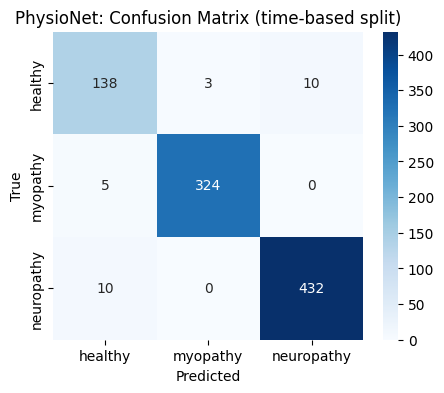

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_pn_test, pn2_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names.values(), yticklabels=label_names.values())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('PhysioNet: Confusion Matrix (time-based split)')
plt.show()

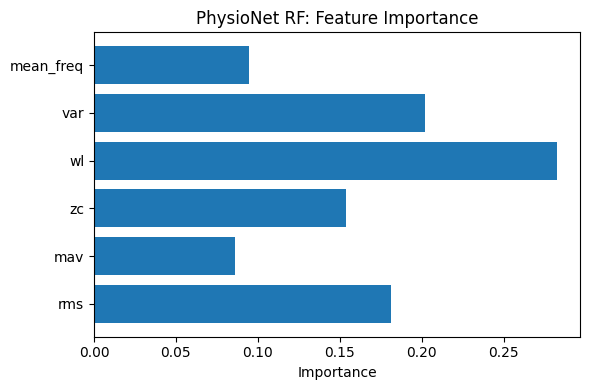

In [48]:
import matplotlib.pyplot as plt

feature_names = ['rms', 'mav', 'zc', 'wl', 'var', 'mean_freq']
importances = rf_pn2.feature_importances_

plt.figure(figsize=(6, 4))
plt.barh(feature_names, importances)
plt.xlabel('Importance')
plt.title('PhysioNet RF: Feature Importance')
plt.tight_layout()
plt.show()

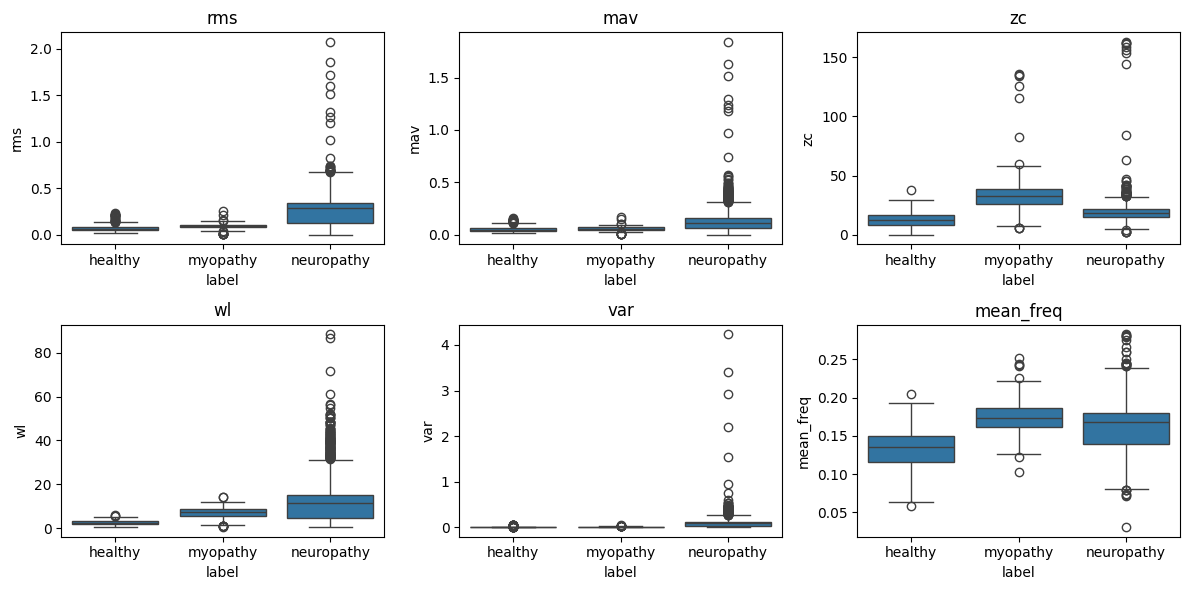

In [49]:
import pandas as pd

feat_df = pd.DataFrame(X_pn_train_feat, columns=feature_names)
feat_df['label'] = [label_names[l] for l in y_pn_train]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, feat in zip(axes.flat, feature_names):
    sns.boxplot(data=feat_df, x='label', y=feat, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report

pn_models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'MLP': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                          early_stopping=True, validation_fraction=0.15, random_state=42),
}

pn_results = {}

for name, clf in pn_models.items():
    clf.fit(X_pn_train_scaled, y_pn_train)
    train_preds = clf.predict(X_pn_train_scaled)
    test_preds = clf.predict(X_pn_test_scaled)
    train_f1 = f1_score(y_pn_train, train_preds, average='macro')
    test_f1 = f1_score(y_pn_test, test_preds, average='macro')
    pn_results[name] = {'train_f1': train_f1, 'test_f1': test_f1}
    print(f"\n=== {name} ===")
    print(f"Train Macro-F1: {train_f1:.4f} | Test Macro-F1: {test_f1:.4f}")
    print(classification_report(y_pn_test, test_preds, target_names=label_names.values()))

# Add your existing RF result (rf_pn2) into the same comparison
rf_pn2_train_preds = rf_pn2.predict(X_pn_train_scaled)
pn_results['Random Forest'] = {
    'train_f1': f1_score(y_pn_train, rf_pn2_train_preds, average='macro'),
    'test_f1': f1_score(y_pn_test, pn2_preds, average='macro')  # pn2_preds already computed earlier
}


=== Logistic Regression ===
Train Macro-F1: 0.8662 | Test Macro-F1: 0.9063
              precision    recall  f1-score   support

     healthy       0.73      0.93      0.82       151
    myopathy       0.96      0.98      0.97       329
  neuropathy       0.98      0.88      0.93       442

    accuracy                           0.92       922
   macro avg       0.89      0.93      0.91       922
weighted avg       0.93      0.92      0.93       922


=== SVM (RBF) ===
Train Macro-F1: 0.8846 | Test Macro-F1: 0.9219
              precision    recall  f1-score   support

     healthy       0.75      0.95      0.84       151
    myopathy       0.98      0.97      0.98       329
  neuropathy       0.99      0.91      0.95       442

    accuracy                           0.94       922
   macro avg       0.91      0.94      0.92       922
weighted avg       0.95      0.94      0.94       922


=== KNN (k=5) ===
Train Macro-F1: 0.9247 | Test Macro-F1: 0.9333
              precision    rec

In [51]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [52]:
!pip install mlflow --quiet
import mlflow

mlflow.set_experiment("emg-gesture-and-diagnosis")

def log_model_run(name, model_type, params, train_f1, test_f1, extra_tags=None):
    with mlflow.start_run(run_name=name):
        mlflow.log_param("model_type", model_type)
        for k, v in params.items():
            mlflow.log_param(k, v)
        mlflow.log_metric("train_macro_f1", train_f1)
        mlflow.log_metric("test_macro_f1", test_f1)
        if extra_tags:
            mlflow.set_tags(extra_tags)b

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.6/144.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

2026/09/22 20:49:16 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/22 20:49:16 INFO mlflow.store.db.utils: Updating database tables
2026/09/22 20:49:18 INFO mlflow.tracking.fluent: Experiment with name 'emg-gesture-and-diagnosis' does not exist. Creating a new experiment.


In [54]:
def log_model_run(name, model_type, params, train_f1, test_f1, extra_tags=None):
    with mlflow.start_run(run_name=name):
        mlflow.log_param("model_type", model_type)
        for k, v in params.items():
            mlflow.log_param(k, v)
        if train_f1 is not None:
            mlflow.log_metric("train_macro_f1", train_f1)
        if test_f1 is not None:
            mlflow.log_metric("test_macro_f1", test_f1)
        if extra_tags:
            mlflow.set_tags(extra_tags)

In [55]:
import joblib
import json
from datetime import datetime

def save_model_version(model, model_name, metrics, params):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    version_dir = f"models/{model_name}/{timestamp}"
    import os
    os.makedirs(version_dir, exist_ok=True)

    joblib.dump(model, f"{version_dir}/model.pkl")
    with open(f"{version_dir}/metadata.json", "w") as f:
        json.dump({"metrics": metrics, "params": params, "timestamp": timestamp}, f, indent=2)

    print(f"Saved {model_name} version to {version_dir}")

save_model_version(rf, "rf_ninapro",
                    {"train_f1": rf_train_f1, "test_f1": rf_test_f1},
                    {"n_estimators": 200, "class_weight": "balanced"})

Saved rf_ninapro version to models/rf_ninapro/20260922_205200


In [57]:
save_model_version(rf_grid.best_estimator_, "rf_ninapro_tuned",
                    {"train_f1": rf_train_f1, "test_f1": rf_tuned_test_f1},
                    rf_grid.best_params_)

save_model_version(svm, "svm_ninapro",
                    {"test_f1": svm_test_f1},
                    {"kernel": "rbf", "class_weight": "balanced"})

save_model_version(rf_pn2, "rf_physionet",
                    {"test_f1": 0.9577},
                    {"n_estimators": 200, "class_weight": "balanced", "split": "time_based_purged"})

Saved rf_ninapro_tuned version to models/rf_ninapro_tuned/20260922_205251
Saved svm_ninapro version to models/svm_ninapro/20260922_205252
Saved rf_physionet version to models/rf_physionet/20260922_205252


In [58]:
save_model_version(svm_grid.best_estimator_, "svm_ninapro_tuned",
                    {"test_f1": svm_tuned_test_f1},
                    svm_grid.best_params_)

Saved svm_ninapro_tuned version to models/svm_ninapro_tuned/20260922_205305
